<a href="https://colab.research.google.com/github/rithwikkolluri-coder/ML-PROJECTS-/blob/main/ML_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading dataset...
Shape: (263040, 26)
Train rows: 174,960  |  Test rows: 87,840

Training XGBoost...

XGBoost results:
  MAE  : 796.77 kWh
  RMSE : 1,643.33 kWh
  R²   : 0.9957

Training LightGBM...

LightGBM results:
  MAE  : 796.66 kWh
  RMSE : 1,621.82 kWh
  R²   : 0.9959

=== Model comparison ===
              MAE      RMSE     R2
model                             
XGBoost   796.765  1643.328  0.996
LightGBM  796.655  1621.817  0.996

Saved feature_importance.png
Saved predicted_vs_actual.png

Saved xgboost_model.json and lightgbm_model.txt

Done.


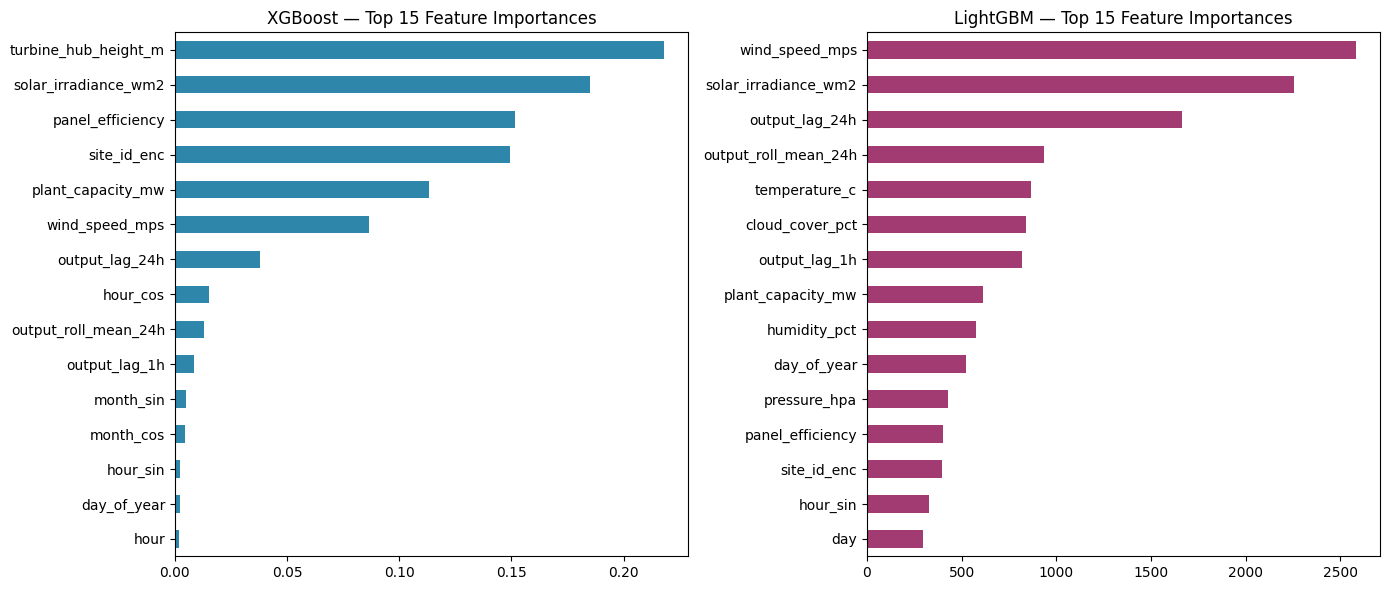

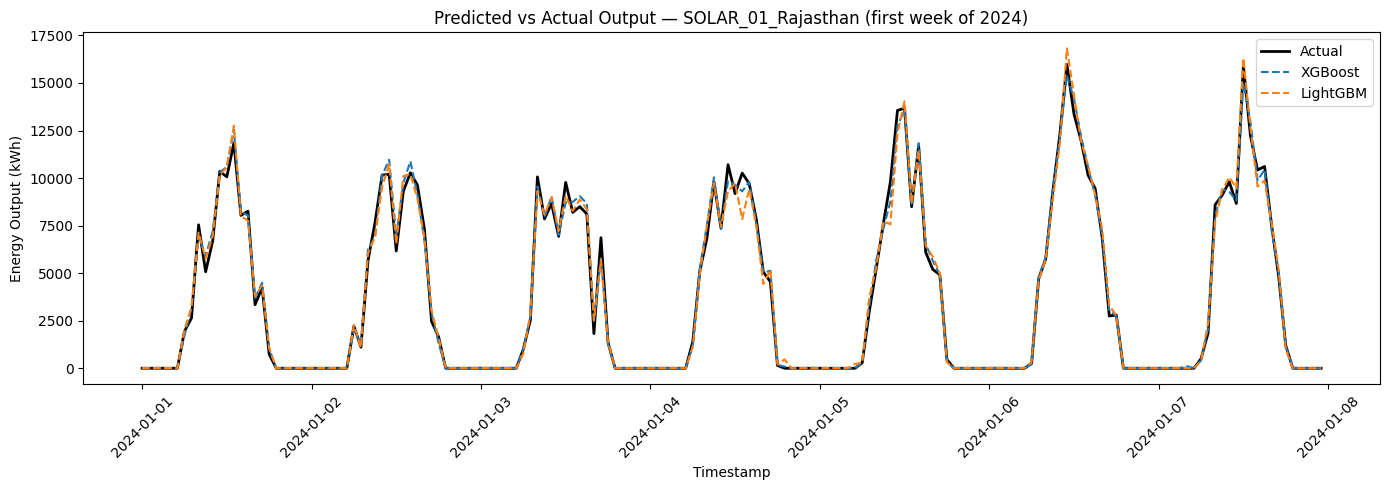

In [ ]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

DATA_PATH = "/content/renewable_energy_dataset.csv"
RANDOM_STATE = 42

# ---------------------------------------------------------------------------
# 1. Load data
# ---------------------------------------------------------------------------
print("Loading dataset...")
df = pd.read_csv(DATA_PATH)
# Timestamps may come as "YYYY-MM-DD HH:MM:SS" (original) or "DD-MM-YYYY HH:MM"
# (if the file was opened/saved in Excel). Handle both automatically.
df["timestamp"] = pd.to_datetime(df["timestamp"], dayfirst=True)
print(f"Shape: {df.shape}")

# ---------------------------------------------------------------------------
# 2. Feature engineering
# ---------------------------------------------------------------------------
df = df.sort_values(["site_id", "timestamp"]).reset_index(drop=True)

# Capacity factor style lag/rolling features per site (helps both models)
df["output_lag_1h"] = df.groupby("site_id")["energy_output_kwh"].shift(1)
df["output_lag_24h"] = df.groupby("site_id")["energy_output_kwh"].shift(24)
df["output_roll_mean_24h"] = (
    df.groupby("site_id")["energy_output_kwh"]
    .transform(lambda s: s.shift(1).rolling(24, min_periods=1).mean())
)

# Encode categoricals
cat_cols = ["site_id", "energy_source", "climate_zone"]
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col + "_enc"] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

# Drop rows where lag features are NaN (start of each site's series)
df = df.dropna(subset=["output_lag_1h", "output_lag_24h", "output_roll_mean_24h"]).reset_index(drop=True)

feature_cols = [
    "plant_capacity_mw", "panel_efficiency", "turbine_hub_height_m",
    "hour", "day", "month", "year", "day_of_week", "day_of_year", "is_weekend",
    "hour_sin", "hour_cos", "month_sin", "month_cos",
    "temperature_c", "humidity_pct", "cloud_cover_pct", "wind_speed_mps",
    "precipitation_mm", "pressure_hpa", "solar_irradiance_wm2",
    "site_id_enc", "energy_source_enc", "climate_zone_enc",
    "output_lag_1h", "output_lag_24h", "output_roll_mean_24h",
]
target_col = "energy_output_kwh"

X = df[feature_cols]
y = df[target_col]

# ---------------------------------------------------------------------------
# 3. Time-based train/test split (train: 2022-2023, test: 2024)
# ---------------------------------------------------------------------------
train_mask = df["timestamp"] < "2024-01-01"
X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

print(f"Train rows: {len(X_train):,}  |  Test rows: {len(X_test):,}")

# ---------------------------------------------------------------------------
# 4. Train models
# ---------------------------------------------------------------------------
def evaluate(name, model, X_te, y_te):
    preds = model.predict(X_te)
    preds = np.clip(preds, 0, None)  # energy output can't be negative
    mae = mean_absolute_error(y_te, preds)
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    r2 = r2_score(y_te, preds)
    print(f"\n{name} results:")
    print(f"  MAE  : {mae:,.2f} kWh")
    print(f"  RMSE : {rmse:,.2f} kWh")
    print(f"  R²   : {r2:.4f}")
    return preds, {"model": name, "MAE": mae, "RMSE": rmse, "R2": r2}

print("\nTraining XGBoost...")
xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
xgb_model.fit(X_train, y_train)
xgb_preds, xgb_metrics = evaluate("XGBoost", xgb_model, X_test, y_test)

print("\nTraining LightGBM...")
lgb_model = LGBMRegressor(
    n_estimators=500,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
)
lgb_model.fit(X_train, y_train)
lgb_preds, lgb_metrics = evaluate("LightGBM", lgb_model, X_test, y_test)

# ---------------------------------------------------------------------------
# 5. Comparison table
# ---------------------------------------------------------------------------
results_df = pd.DataFrame([xgb_metrics, lgb_metrics]).set_index("model")
print("\n=== Model comparison ===")
print(results_df.round(3))
results_df.to_csv("model_comparison.csv")

# ---------------------------------------------------------------------------
# 6. Feature importance plots
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

xgb_importance = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values()
xgb_importance.tail(15).plot(kind="barh", ax=axes[0], color="#2E86AB")
axes[0].set_title("XGBoost — Top 15 Feature Importances")

lgb_importance = pd.Series(lgb_model.feature_importances_, index=feature_cols).sort_values()
lgb_importance.tail(15).plot(kind="barh", ax=axes[1], color="#A23B72")
axes[1].set_title("LightGBM — Top 15 Feature Importances")

plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
print("\nSaved feature_importance.png")

# ---------------------------------------------------------------------------
# 7. Predicted vs Actual plot (sample week, one site)
# ---------------------------------------------------------------------------
sample_site = df.loc[~train_mask, "site_id"].iloc[0]
sample_mask = (~train_mask) & (df["site_id"] == sample_site)
sample_idx = df[sample_mask].index[:24 * 7]  # first week of test period for that site

plot_df = pd.DataFrame({
    "timestamp": df.loc[sample_idx, "timestamp"],
    "actual": y.loc[sample_idx],
    "xgboost": pd.Series(xgb_preds, index=X_test.index).loc[sample_idx],
    "lightgbm": pd.Series(lgb_preds, index=X_test.index).loc[sample_idx],
})

plt.figure(figsize=(14, 5))
plt.plot(plot_df["timestamp"], plot_df["actual"], label="Actual", linewidth=2, color="black")
plt.plot(plot_df["timestamp"], plot_df["xgboost"], label="XGBoost", linestyle="--")
plt.plot(plot_df["timestamp"], plot_df["lightgbm"], label="LightGBM", linestyle="--")
plt.title(f"Predicted vs Actual Output — {sample_site} (first week of 2024)")
plt.xlabel("Timestamp")
plt.ylabel("Energy Output (kWh)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("predicted_vs_actual.png", dpi=150)
print("Saved predicted_vs_actual.png")

# ---------------------------------------------------------------------------
# 8. Save trained models
# ---------------------------------------------------------------------------
xgb_model.save_model("xgboost_model.json")
lgb_model.booster_.save_model("lightgbm_model.txt")
print("\nSaved xgboost_model.json and lightgbm_model.txt")

print("\nDone.")

Loading data...
  263,040 rows loaded, 10 sites, 2022-01-01 00:00:00 -> 2024-12-31 23:00:00
Cleaning / imputing...
Engineering lag & rolling features...
  262,800 rows remain after dropping warm-up rows
Encoding categorical features...
Splitting chronologically (80% train / 20% test)...
  Train: 210,240 rows | Test: 52,560 rows
Training XGBoost and LightGBM...

=== Overall Test-Set Performance ===
  XGBoost     RMSE=1901.68  MAE=970.02  R2=0.9947
  LightGBM    RMSE=1812.85  MAE=910.65  R2=0.9952

=== Performance by Energy Source ===
   Model Source        RMSE         MAE       R2
 XGBoost  Solar 1016.518236  513.067103 0.997908
 XGBoost   Wind 2489.870559 1426.969755 0.987583
LightGBM  Solar  956.956643  475.813498 0.998146
LightGBM   Wind 2378.469273 1345.485289 0.988669

Top 10 features (XGBoost):
                    feature  xgb_importance  lgbm_importance
site_id_WIND_05_Maharashtra        0.311233         0.006774
        energy_source_Solar        0.202906         0.000430
     

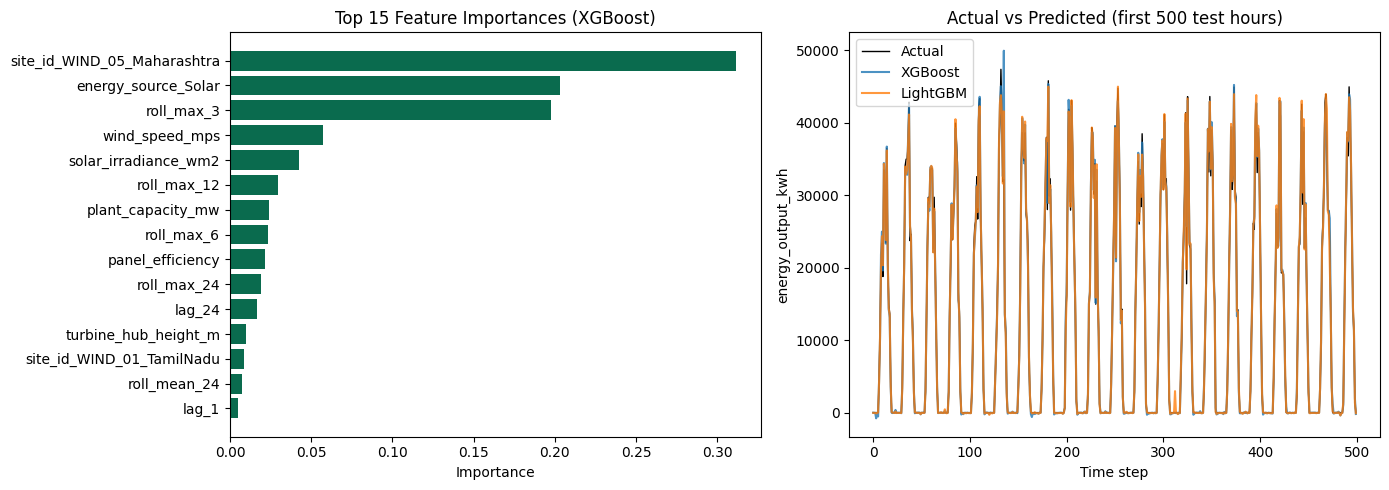

In [ ]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# ----------------------------------------------------------------------
# CONFIG
# ----------------------------------------------------------------------
DATA_PATH = "renewable_energy_dataset.csv"   # change path if needed
TARGET = "energy_output_kwh"
TIME_COL = "timestamp"
GROUP_COL = "site_id"                        # rolling/lag features computed per site
TEST_FRACTION = 0.20                         # last 20% of the timeline is the test set
LAGS = [1, 2, 3, 6, 12, 24]
ROLL_WINDOWS = [3, 6, 12, 24]
RANDOM_STATE = 42


# ----------------------------------------------------------------------
# 1. LOAD DATA
# ----------------------------------------------------------------------
def load_data(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)

    # The timestamps are formatted as DD-MM-YYYY HH:MM
    df[TIME_COL] = pd.to_datetime(df[TIME_COL], format="%d-%m-%Y %H:%M")

    # Sort chronologically within each site — required before any
    # lag/rolling feature or shift-based operation.
    df = df.sort_values([GROUP_COL, TIME_COL]).reset_index(drop=True)
    return df


# ----------------------------------------------------------------------
# 2. CLEAN / IMPUTE
# ----------------------------------------------------------------------
def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # panel_efficiency / solar_irradiance_wm2 are structurally missing
    # for wind sites, and turbine_hub_height_m is structurally missing
    # for solar sites. 0 is a safe, meaningful placeholder — the
    # `energy_source` flag lets the models learn the distinction.
    structural_zero_cols = ["panel_efficiency", "turbine_hub_height_m", "solar_irradiance_wm2"]
    for col in structural_zero_cols:
        if col in df.columns:
            df[col] = df[col].fillna(0)

    # Genuine sensor gaps in the weather columns: forward/backward-fill
    # within each site's own chronological series (time-series-safe —
    # no information crosses site boundaries).
    weather_cols = ["temperature_c", "humidity_pct", "cloud_cover_pct", "wind_speed_mps"]
    for col in weather_cols:
        if col in df.columns:
            df[col] = df.groupby(GROUP_COL)[col].transform(lambda s: s.ffill().bfill())

    # Drop any residual fully-empty rows for the target itself.
    df = df.dropna(subset=[TARGET]).reset_index(drop=True)
    return df


# ----------------------------------------------------------------------
# 3. FEATURE ENGINEERING
# ----------------------------------------------------------------------
def add_lag_and_rolling_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    grp = df.groupby(GROUP_COL)[TARGET]

    # Lag features (autoregressive signal)
    for lag in LAGS:
        df[f"lag_{lag}"] = grp.shift(lag)

    # Rolling statistics — shift(1) first so the window only uses
    # information strictly BEFORE the current timestamp (no leakage).
    shifted = df.groupby(GROUP_COL)[TARGET].shift(1)
    df["_shifted_target"] = shifted
    for w in ROLL_WINDOWS:
        roll = df.groupby(GROUP_COL)["_shifted_target"].rolling(window=w, min_periods=1)
        df[f"roll_mean_{w}"] = roll.mean().reset_index(level=0, drop=True)
        df[f"roll_std_{w}"] = roll.std().reset_index(level=0, drop=True)
        df[f"roll_min_{w}"] = roll.min().reset_index(level=0, drop=True)
        df[f"roll_max_{w}"] = roll.max().reset_index(level=0, drop=True)
    df = df.drop(columns=["_shifted_target"])

    # Rows without full lag/rolling history (first `max(LAGS)` hours of
    # each site) can't be used for training — drop them.
    feature_cols = [c for c in df.columns if c.startswith("lag_") or c.startswith("roll_")]
    df = df.dropna(subset=feature_cols).reset_index(drop=True)
    return df


def encode_categoricals(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    cat_cols = ["energy_source", "climate_zone", "site_id"]
    cat_cols = [c for c in cat_cols if c in df.columns]
    df = pd.get_dummies(df, columns=cat_cols, drop_first=False)
    return df


# ----------------------------------------------------------------------
# 4. CHRONOLOGICAL TRAIN / TEST SPLIT
# ----------------------------------------------------------------------
def chronological_split(df: pd.DataFrame, test_fraction: float = TEST_FRACTION):
    """
    Global time cutoff: the earliest (1 - test_fraction) of the
    timeline is training data, the most recent `test_fraction` is the
    held-out test set. All sites share the same cutoff timestamp, so
    the model is always evaluated on genuinely unseen future data.
    """
    cutoff = df[TIME_COL].quantile(1 - test_fraction)
    train_df = df[df[TIME_COL] <= cutoff].reset_index(drop=True)
    test_df = df[df[TIME_COL] > cutoff].reset_index(drop=True)
    return train_df, test_df


# ----------------------------------------------------------------------
# 5. MODEL TRAINING
# ----------------------------------------------------------------------
def get_feature_columns(df: pd.DataFrame) -> list:
    exclude = {TARGET, TIME_COL}
    return [c for c in df.columns if c not in exclude]


def train_models(X_train, y_train):
    xgb_model = XGBRegressor(
        n_estimators=600,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        reg_alpha=0.0,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    xgb_model.fit(X_train, y_train)

    lgbm_model = LGBMRegressor(
        n_estimators=600,
        max_depth=-1,
        num_leaves=63,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    )
    lgbm_model.fit(X_train, y_train)

    return xgb_model, lgbm_model


# ----------------------------------------------------------------------
# 6. EVALUATION
# ----------------------------------------------------------------------
def evaluate(y_true, y_pred) -> dict:
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {"RMSE": rmse, "MAE": mae, "R2": r2}


def evaluate_by_source(test_df, y_pred, model_name):
    results = []
    source_cols = [c for c in test_df.columns if c.startswith("energy_source_")]
    for col in source_cols:
        mask = test_df[col] == 1
        if mask.sum() == 0:
            continue
        metrics = evaluate(test_df.loc[mask, TARGET], y_pred[mask.values])
        source_name = col.replace("energy_source_", "")
        results.append({"Model": model_name, "Source": source_name, **metrics})
    return results


# ----------------------------------------------------------------------
# MAIN
# ----------------------------------------------------------------------
def main():
    print("Loading data...")
    df = load_data(DATA_PATH)
    print(f"  {len(df):,} rows loaded, {df[GROUP_COL].nunique()} sites, "
          f"{df[TIME_COL].min()} -> {df[TIME_COL].max()}")

    print("Cleaning / imputing...")
    df = clean_data(df)

    print("Engineering lag & rolling features...")
    df = add_lag_and_rolling_features(df)
    print(f"  {len(df):,} rows remain after dropping warm-up rows")

    print("Encoding categorical features...")
    df = encode_categoricals(df)

    print("Splitting chronologically (80% train / 20% test)...")
    train_df, test_df = chronological_split(df)
    print(f"  Train: {len(train_df):,} rows | Test: {len(test_df):,} rows")

    feature_cols = get_feature_columns(df)
    X_train, y_train = train_df[feature_cols], train_df[TARGET]
    X_test, y_test = test_df[feature_cols], test_df[TARGET]

    print("Training XGBoost and LightGBM...")
    xgb_model, lgbm_model = train_models(X_train, y_train)

    xgb_pred = xgb_model.predict(X_test)
    lgbm_pred = lgbm_model.predict(X_test)

    # ---- Overall metrics ----
    print("\n=== Overall Test-Set Performance ===")
    summary = []
    for name, pred in [("XGBoost", xgb_pred), ("LightGBM", lgbm_pred)]:
        m = evaluate(y_test, pred)
        summary.append({"Model": name, **m})
        print(f"  {name:10s}  RMSE={m['RMSE']:.2f}  MAE={m['MAE']:.2f}  R2={m['R2']:.4f}")

    summary_df = pd.DataFrame(summary)

    # ---- Metrics split by energy source (Solar vs Wind) ----
    print("\n=== Performance by Energy Source ===")
    by_source = []
    by_source += evaluate_by_source(test_df, xgb_pred, "XGBoost")
    by_source += evaluate_by_source(test_df, lgbm_pred, "LightGBM")
    by_source_df = pd.DataFrame(by_source)
    print(by_source_df.to_string(index=False))

    # ---- Feature importance ----
    importances = pd.DataFrame({
        "feature": feature_cols,
        "xgb_importance": xgb_model.feature_importances_,
        "lgbm_importance": lgbm_model.feature_importances_ / lgbm_model.feature_importances_.sum(),
    }).sort_values("xgb_importance", ascending=False)

    print("\nTop 10 features (XGBoost):")
    print(importances.head(10).to_string(index=False))

    # ---- Plots ----
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    top_feats = importances.head(15).sort_values("xgb_importance")
    axes[0].barh(top_feats["feature"], top_feats["xgb_importance"], color="#0A6B4E")
    axes[0].set_title("Top 15 Feature Importances (XGBoost)")
    axes[0].set_xlabel("Importance")

    sample = min(500, len(y_test))
    axes[1].plot(y_test.values[:sample], label="Actual", color="black", linewidth=1)
    axes[1].plot(xgb_pred[:sample], label="XGBoost", alpha=0.8)
    axes[1].plot(lgbm_pred[:sample], label="LightGBM", alpha=0.8)
    axes[1].set_title("Actual vs Predicted (first {} test hours)".format(sample))
    axes[1].set_xlabel("Time step")
    axes[1].set_ylabel(TARGET)
    axes[1].legend()

    plt.tight_layout()
    plt.savefig("model_results.png", dpi=150)
    print("\nSaved plot to model_results.png")

    summary_df.to_csv("overall_metrics.csv", index=False)
    by_source_df.to_csv("metrics_by_source.csv", index=False)
    print("Saved overall_metrics.csv and metrics_by_source.csv")


if __name__ == "__main__":
    main()